In [ ]:
!pip install nvcc4jupyter
%load_ext nvcc4jupyter
!apt install libopencv-dev
!apt install -y apt-file
!dpkg -l | grep opencv

Detected platform "Colab". Running its setup...
Source files will be saved in "/tmp/tmporx4lt1d".
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  at-spi2-core gsettings-desktop-schemas gstreamer1.0-plugins-base
  libatk-bridge2.0-0 libatk1.0-0 libatk1.0-data libatspi2.0-0 libavcodec-dev
  libavformat-dev libavutil-dev libcdparanoia0 libcharls2 libdc1394-dev
  libdouble-conversion3 libexif-dev libexif-doc libexif12 libgdcm-dev
  libgdcm3.0 libgl2ps1.4 libglew2.2 libgphoto2-6 libgphoto2-dev
  libgphoto2-l10n libgphoto2-port12 libgstreamer-plugins-base1.0-0 libgtk-3-0
  libgtk-3-bin libgtk-3-common libilmbase-dev libilmbase25
  libopencv-calib3d-dev libopencv-calib3d4.5d libopencv-contrib-dev
  libopencv-contrib4.5d libopencv-core-dev libopencv-core4.5d
  libopencv-dnn-dev libopencv-dnn4.5d libopencv-features2d-dev
  libopencv-features2d4.5d libopencv-flann-dev libopencv-flann4.5d
  lib

In [ ]:
# @title
#%%javascript
%%writefile blur.cu

//
// Input:  input.ppm (P6 RGB)
// Output: output.pgm (P5 grayscale / black-white)
//
// You are GIVEN: PPM/PGM I/O + grayscale kerne
// You must COMPLETE: threshold kernel + its launch + copy back

#include <cstdio>
#include <cstdlib>
#include <cstdint>
#include <cstring>
#include <cuda_runtime.h>

#define CHECK_CUDA(call) do { \
  cudaError_t err = (call); \
  if (err != cudaSuccess) { \
    fprintf(stderr, "CUDA error %s:%d: %s\n", __FILE__, __LINE__, cudaGetErrorString(err)); \
    exit(1); \
  } \
} while (0)

__constant__ float h_filter[5][5] = {
  {1.0/256.0, 4.0/256.0, 6.0/256.0, 4.0/256.0, 1.0/256.0},
  {4.0/256.0, 16.0/256.0, 24.0/256.0, 16.0/256.0, 4.0/256.0},
  {6.0/256.0, 24.0/256.0, 36.0/256.0, 24.0/256.0, 6.0/256.0},
  {4.0/256.0, 16.0/256.0, 24.0/256.0, 16.0/256.0, 4.0/256.0},
  {1.0/256.0, 4.0/256.0, 6.0/256.0, 4.0/256.0, 1.0/256.0}
};
/*
__constant__ float h_filter[5][5] = {
  {1, 4, 6, 4, 1},
  {4, 16, 24, 16, 4},
  {6, 24, 36, 24, 6},
  {4, 16, 24, 16, 4},
  {1, 4, 6, 4, 1}
};*/

// ------------------------------------------------------------
// PPM/PGM I/O (no libraries)
// Supports P6 PPM (binary RGB, maxval 255) with optional comments.
// ------------------------------------------------------------

static void skip_ws_and_comments(FILE* f) {
  int c;
  while ((c = fgetc(f)) != EOF) {
    if (c == '#') { // comment line
      while ((c = fgetc(f)) != EOF && c != '\n') {}
      continue;
    }
    if (c == ' ' || c == '\n' || c == '\r' || c == '\t') continue;
    ungetc(c, f);
    break;
  }
}

static bool read_ppm_p6(const char* path, uint8_t** rgb_out, int* w_out, int* h_out) {
  FILE* fp = fopen(path, "rb");
  if (!fp) { perror("fopen"); return false; }

  char magic[3] = {0};
  if (fscanf(fp, "%2s", magic) != 1) { fclose(fp); return false; }
  if (strcmp(magic, "P6") != 0) {
    fprintf(stderr, "ERROR: %s is not P6 PPM (got %s)\n", path, magic);
    fclose(fp);
    return false;
  }

  skip_ws_and_comments(fp);
  int w = 0, h = 0, maxv = 0;
  if (fscanf(fp, "%d", &w) != 1) { fclose(fp); return false; }
  skip_ws_and_comments(fp);
  if (fscanf(fp, "%d", &h) != 1) { fclose(fp); return false; }
  skip_ws_and_comments(fp);
  if (fscanf(fp, "%d", &maxv) != 1) { fclose(fp); return false; }

  if (w <= 0 || h <= 0 || maxv != 255) {
    fprintf(stderr, "ERROR: unsupported PPM header w=%d h=%d maxv=%d (need maxv=255)\n", w, h, maxv);
    fclose(fp);
    return false;
  }

  fgetc(fp); // consume one whitespace char after maxv

  size_t nbytes = (size_t)w * (size_t)h * 3;
  uint8_t* rgb = (uint8_t*)malloc(nbytes);
  if (!rgb) { fclose(fp); return false; }

  size_t got = fread(rgb, 1, nbytes, fp);
  fclose(fp);

  if (got != nbytes) {
    fprintf(stderr, "ERROR: short read. expected %zu bytes, got %zu\n", nbytes, got);
    free(rgb);
    return false;
  }

  *rgb_out = rgb;
  *w_out = w;
  *h_out = h;
  return true;
}

static bool write_pgm_p5(const char* path, const uint8_t* gray, int w, int h) {
  FILE* fp = fopen(path, "wb");
  if (!fp) { perror("fopen"); return false; }
  fprintf(fp, "P5\n%d %d\n255\n", w, h);
  size_t nbytes = (size_t)w * (size_t)h;
  size_t wrote = fwrite(gray, 1, nbytes, fp);
  fclose(fp);
  return wrote == nbytes;
}

// ------------------------------------------------------------
// GIVEN grayscale kernel (same formula idea as class: rgb_to_grayscale_02052026)
// gray = 3/10 R + 6/10 G + 1/10 B
// Input is interleaved RGB (PPM): rgb[3*i + {0,1,2}]
// ------------------------------------------------------------
__global__ void rgb_to_gray_interleaved_kernel(const uint8_t* rgb, uint8_t* gr,
                                               unsigned int width, unsigned int height) {
  unsigned int col = blockIdx.x * blockDim.x + threadIdx.x;
  unsigned int row = blockIdx.y * blockDim.y + threadIdx.y;

  if (row < height && col < width) {
    unsigned int i = row * width + col;
    unsigned int base = 3 * i;
    uint8_t r = rgb[base + 0];
    uint8_t g = rgb[base + 1];
    uint8_t b = rgb[base + 2];
    gr[i] = (uint8_t)((3 * r + 6 * g + 1 * b) / 10);
  }
}

__global__ void threshold_kernel(uint8_t *gr, const uint8_t T, unsigned int width, unsigned int height){
    unsigned int col = blockIdx.x * blockDim.x + threadIdx.x;
    unsigned int row = blockIdx.y * blockDim.y + threadIdx.y;
    if (row < height && col < width) {
        unsigned int i = row * width + col;
        if(gr[i] >= T){
            gr[i] = (uint8_t)255;
        }else{
            gr[i] = (uint8_t)0;
        }
    }
}

__global__ void gaussian_blur_kernel(uint8_t *origional, uint8_t *blurred, unsigned int width, unsigned int height, unsigned int blursize){
    unsigned int col = blockIdx.x * blockDim.x + threadIdx.x;
    unsigned int row = blockIdx.y * blockDim.y + threadIdx.y;
    if (row < height && col < width){
        int sum = 0;
        int count = 0;
        for(int i = row - blursize; i < row + blursize + 1; i++){
            for(int j = col - blursize; j < col + blursize + 1; j++){
                if(i >= 0 && i < height && j >= 0 && j < width){
                    sum += (int)origional[i * width + j];
                    count++;
                }
            }
        }
        blurred[row * width + col] = (uint8_t)(sum/count);
        //blurred[row * width + col] = (uint8_t)(average/((2*blursize + 1)*(2*blursize + 1)));
   }
}
__global__ void blur_shared_kernel(uint8_t *origional, uint8_t *blurred, unsigned int width, unsigned int height, int blursize){
    // Compute global pixel coordinates
    unsigned int col = blockIdx.x * blockDim.x + threadIdx.x;
    unsigned int row = blockIdx.y * blockDim.y + threadIdx.y;

    // Shared memory tile dimensions (block + halo)
    unsigned int shared_width = blockDim.x + 2 * blursize;
    unsigned int shared_height = blockDim.y + 2 * blursize;

    // Dynamic shared memory
    extern __shared__ uint8_t tile[];

    // Each thread loads multiple pixels in the shared memory tile (including halo)
    for(int i = threadIdx.y; i < (int)shared_height; i += blockDim.y){
        for(int j = threadIdx.x; j < (int)shared_width; j += blockDim.x){
            int global_x = blockIdx.x * blockDim.x + j - blursize;
            int global_y = blockIdx.y * blockDim.y + i - blursize;

            if(global_x >= 0 && global_x < (int)width && global_y >= 0 && global_y < (int)height){
                tile[i * shared_width + j] = origional[global_y * width + global_x];
            }else{
                tile[i * shared_width + j] = 0;
            }
        }
    }

    __syncthreads();

    // Compute blur only for valid pixel coordinates
    if(col < width && row < height){
        int sum = 0;
        int count = 0;

        unsigned int shared_x = threadIdx.x + blursize;
        unsigned int shared_y = threadIdx.y + blursize;
        for(int i = -blursize; i <= blursize; i++){
            for(int j = -blursize; j <= blursize; j++){
                sum += tile[(shared_y + i) * shared_width + (shared_x + j)];
                count++;
            }
        }
        blurred[row * width + col] = (uint8_t)(sum/count);
    }
}
__global__ void gaussian_blur_shared_kernel(uint8_t *origional, uint8_t *blurred, unsigned int width, unsigned int height, int blursize){
    // Compute global pixel coordinates
    unsigned int col = blockIdx.x * blockDim.x + threadIdx.x;
    unsigned int row = blockIdx.y * blockDim.y + threadIdx.y;

    // Shared memory tile dimensions (block + halo)
    unsigned int shared_width = blockDim.x + 2 * blursize;
    unsigned int shared_height = blockDim.y + 2 * blursize;

    // Dynamic shared memory
    extern __shared__ uint8_t tile[];

    // Each thread loads multiple pixels in the shared memory tile (including halo)
    for(int i = threadIdx.y; i < (int)shared_height; i += blockDim.y){
        for(int j = threadIdx.x; j < (int)shared_width; j += blockDim.x){
            int global_x = blockIdx.x * blockDim.x + j - blursize;
            int global_y = blockIdx.y * blockDim.y + i - blursize;

            if(global_x >= 0 && global_x < (int)width && global_y >= 0 && global_y < (int)height){
                tile[i * shared_width + j] = origional[global_y * width + global_x];
            }else{
                tile[i * shared_width + j] = 0;
            }
        }
    }

    __syncthreads();

    // Compute blur only for valid pixel coordinates
    if(col < width && row < height){
        float sum = 0;
        int x = 0;
        int y = 0;

        unsigned int shared_x = threadIdx.x + blursize;
        unsigned int shared_y = threadIdx.y + blursize;
        for(int i = -blursize; i <= blursize; i++, x++){
            for(int j = -blursize; j <= blursize; j++, y++){
                sum += tile[(shared_y + i) * shared_width + (shared_x + j)] * h_filter[x][y];
            }
        }

        blurred[row * width + col] = (uint8_t)(sum);
    }
}

static uint64_t checksum_u8(const uint8_t* data, size_t n) {
  uint64_t s = 0;
  for (size_t i = 0; i < n; i++) s += data[i];
  return s;
}

int main(int argc, char** argv) {
  int blursize = 2;
  if (argc < 2) {
    fprintf(stderr, "Usage: %s input.ppm [output.pgm]\n", argv[0]);
    return 1;
  }
  if(argc == 4){
    blursize = atoi(argv[3]);
  }
  printf("blursize: %d\n", blursize);
  const char* in_path  = argv[1];
  const char* out_path = (argc >= 3) ? argv[2] : "output.pgm";

  // Read PPM on CPU
  uint8_t* h_rgb = nullptr;
  int width = 0, height = 0;
  if (!read_ppm_p6(in_path, &h_rgb, &width, &height)) {
    fprintf(stderr, "ERROR: failed to read %s\n", in_path);
    return 1;
  }
  printf("Loaded %s: %dx%d (P6)\n", in_path, width, height);

  size_t n_pixels = (size_t)width * (size_t)height;
  size_t rgb_bytes  = n_pixels * 3;
  size_t gray_bytes = n_pixels;

  // Host output buffer (final image)
  uint8_t* h_out = (uint8_t*)malloc(gray_bytes);
  if (!h_out) { fprintf(stderr, "malloc failed\n"); free(h_rgb); return 1; }

  // Device buffers
  uint8_t *d_rgb=nullptr, *d_out=nullptr, *d_gray=nullptr;
  CHECK_CUDA(cudaMalloc((void**)&d_rgb,  rgb_bytes));
  CHECK_CUDA(cudaMalloc((void**)&d_gray, gray_bytes));
  CHECK_CUDA(cudaMalloc((void**)&d_out,  gray_bytes));

  CHECK_CUDA(cudaMemcpy(d_rgb, h_rgb, rgb_bytes, cudaMemcpyHostToDevice));

  // Standard 2D grid/block
  dim3 block(16, 16, 1);
  dim3 grid((width  + block.x - 1) / block.x, (height + block.y - 1) / block.y, 1);

  printf("Block=(%d,%d) Grid=(%d,%d)\n", block.x, block.y, grid.x, grid.y);

  // 1) GPU grayscale (given)
  rgb_to_gray_interleaved_kernel<<<grid, block>>>(d_rgb, d_gray, (unsigned)width, (unsigned)height);
  cudaDeviceSynchronize();
  CHECK_CUDA(cudaGetLastError());


  // 2) GPU threshold (student)
  const uint8_t T = 128;

  // TODO: launch your threshold kernel here:
  // threshold_kernel<<<grid, block>>>(d_gray, d_out, (unsigned)width, (unsigned)height, T);
  // CHECK_CUDA(cudaGetLastError());

    //threshold_kernel <<<grid, block>>> (d_gray, T, (unsigned)width, (unsigned)height);
    //cudaDeviceSynchronize();
    //CHECK_CUDA(cudaGetLastError());

    size_t sharedMemSize = (block.x + 2*blursize) * (block.y + 2*blursize) * sizeof(uint8_t);
    //blur_shared_kernel <<<grid, block, sharedMemSize>>> (d_gray, d_out, width, height, blursize);
    gaussian_blur_shared_kernel <<<grid, block, sharedMemSize>>> (d_gray, d_out, width, height, blursize);
    cudaDeviceSynchronize();
    CHECK_CUDA(cudaGetLastError());

    CHECK_CUDA(cudaMemcpy(h_out, d_out, gray_bytes, cudaMemcpyDeviceToHost));
  // TODO: copy d_out back to h_out
  // CHECK_CUDA(cudaMemcpy(h_out, d_out, gray_bytes, cudaMemcpyDeviceToHost));

  // Write output PGM
  if (!write_pgm_p5(out_path, h_out, width, height)) {
    fprintf(stderr, "ERROR: failed to write %s\n", out_path);
    return 1;
  }

  // Stats for checking
  uint64_t cs = checksum_u8(h_out, n_pixels);
  size_t white = 0;
  for (size_t i = 0; i < n_pixels; i++) if (h_out[i] == 255) white++;

  printf("Wrote %s (P5)\n", out_path);
  printf("Checksum(sum bytes) = %llu\n", (unsigned long long)cs);
  printf("WHITE PIXELS = %zu out of %zu\n", white, n_pixels);

  // cleanup
  free(h_rgb);
  free(h_out);
  CHECK_CUDA(cudaFree(d_rgb));
  CHECK_CUDA(cudaFree(d_gray));
  CHECK_CUDA(cudaFree(d_out));

  return 0;
}


Writing threshold_starter.cu


In [ ]:
# @title
%%writefile makefile
CC = nvcc

# Compiler flags //unecessary compiler flags // -Wall: warnings -g: debug info
CFLAGS = -Xcudafe --diag_suppress=2464 -arch=sm_75

# Source files
SRCS = blur.cu

# Object files
OBJS = $(SRCS:.cu=.o)

# Executable name
TARGET = assignment4

# Default target
all: $(TARGET)

# Linking the executable // $@ sourcefile $^ all files/prerequesites
$(TARGET): $(OBJS)
	$(CC) $(CFLAGS) -o $@ $^

# Compiling .c to .o //$< sourcefile $@ generated file name
%.o: %.cu
	$(CC) $(CFLAGS) -c $< -o $@

# Clean up // build clean
clean:
	rm -f $(OBJS) $(TARGET)
.PHONY: all clean


Overwriting makefile


In [4]:
!make clean

rm -f threshold_starter.o assignment4


In [5]:
!make

nvcc -Xcudafe --diag_suppress=2464 -arch=sm_75 -c threshold_starter.cu -o threshold_starter.o
threshold_starter.cu(322): warning #177-D: variable "T" was declared but never referenced
    const uint8_t T = 128;
                  ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

nvcc -Xcudafe --diag_suppress=2464 -arch=sm_75 -o assignment4 threshold_starter.o


In [ ]:
!./blur input.ppm output.pgm

blursize: 2
Loaded input.ppm: 900x600 (P6)
Block=(16,16) Grid=(57,38)
Wrote output.pgm (P5)
Checksum(sum bytes) = 29538284
WHITE PIXELS = 0 out of 540000


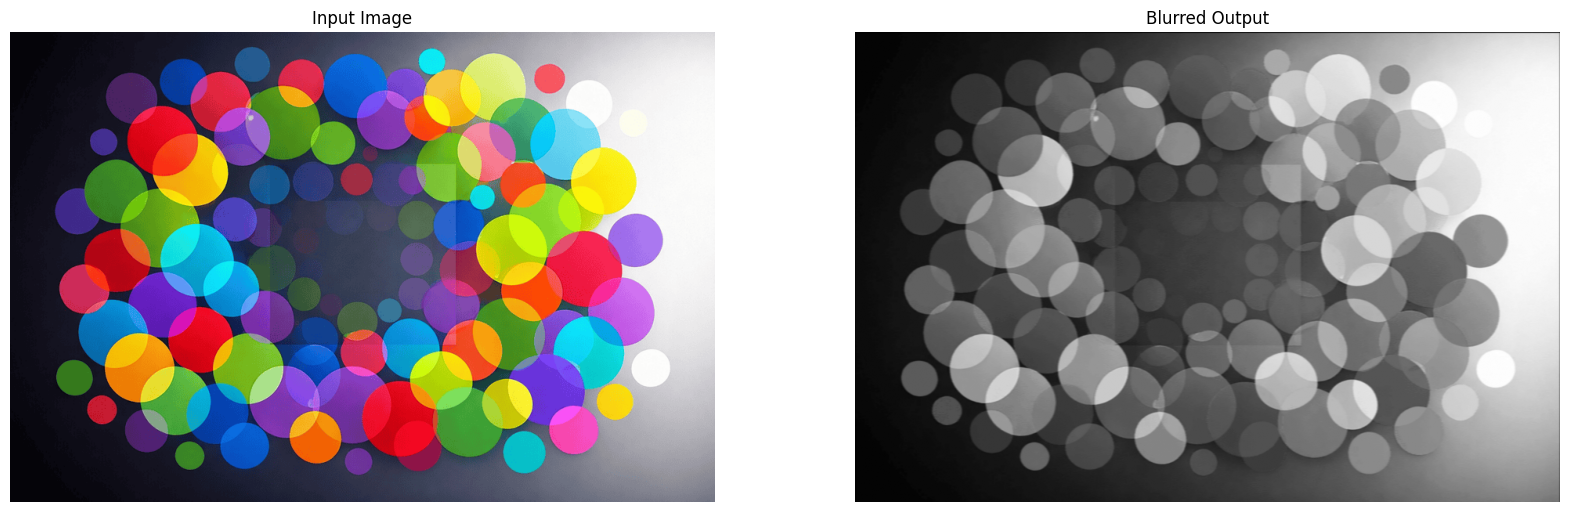

In [6]:
import matplotlib.pyplot as plt
import cv2

# Read images
input_img = cv2.imread('input.ppm', cv2.IMREAD_COLOR)
input_img = cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB)  # Convert BGR->RGB

output_img = cv2.imread('output.pgm', cv2.IMREAD_GRAYSCALE)  # CUDA output is grayscale

# Display side by side
plt.figure(figsize=(20,10))

plt.subplot(1,2,1)
plt.imshow(input_img)
plt.title("Input Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(output_img, cmap='gray')
plt.title("Blurred Output")
plt.axis('off')

plt.show()